# MLFlow
Nesta etapa vamos entrar mais a fundo na biblioteca `MLFlow`. Ela vai nos ajudar com os 4 pontos abaixo:
1. Experiment Tracking:
    1. É onde registramos tudo o que aconteceu durante um treinamento (cada treinamento é chamado de `run`);
2. Experiments:
    1. Dentro de cada experimento fica os runs, normalmente um experimento é criado por `problemas`
3. Runs:
    1. É nele que salvamos, *parametros*, *métricas*, *artifacts (imagens, texto, csv)*, *modelos*

In [1]:
import pandas as pd
from feast import FeatureStore

In [2]:
import mlflow
import joblib
import logging
from pathlib import Path

from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, accuracy_score

logging.getLogger("mlflow.utils.requirements_utils").setLevel(logging.ERROR)

In [3]:
# subindo o db para guardar as métricas
mlflow.set_tracking_uri("sqlite:///mlflow.db")

In [4]:
# criando o experimento
EXPERIMENT_NAME = 'ieee_cis_fraud'
mlflow.set_experiment(EXPERIMENT_NAME)

2026/07/22 01:59:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/22 01:59:47 INFO mlflow.store.db.utils: Updating database tables
2026/07/22 01:59:49 INFO mlflow.tracking.fluent: Experiment with name 'ieee_cis_fraud' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:///M:/disco '
 'M/Programacao/PythonProjects/Repos/MachineLearningEngineering/05_experiment_tracking/mlruns/1'), creation_time=1784696389628, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1784696389628, lifecycle_stage='active', name='ieee_cis_fraud', tags={}, trace_location=None, workspace='default'>

In [5]:
# arquivos dos modelos
ARTIFACTS = Path('../artfacts/')
MODEL_MVP_V0 = ARTIFACTS / 'model_mvp_v0.joblib'
MODEL_MVP_THRESHOULD_TUNED_V0 = ARTIFACTS / 'model_mvp_threshould_tuned_v0.joblib'

In [6]:
model_mvp_v0 = joblib.load(MODEL_MVP_V0)
model_mvp_threshould_tuned_v0 = joblib.load(MODEL_MVP_THRESHOULD_TUNED_V0)

M:\disco M\Programacao\PythonProjects\VENVS\env\Lib\site-packages\joblib\numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape


In [7]:
check_is_fitted(model_mvp_v0)

In [8]:
# Feature Store
store = FeatureStore("../03_feature_store/")

M:\disco M\Programacao\PythonProjects\VENVS\env\Lib\site-packages\dask\dataframe\utils.py:274: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  "m": np.timedelta64(1),


In [9]:
# Pegando as features
fv = store.get_feature_view(
    "transaction_features"
)

features = [
    f"transaction_features:{field.name}"
    for field in fv.schema
    if field.name not in {
        "transaction_id",
        "transaction_time",
        "label"
    }
]

# dataframe com os ids necessarios
df_entity = pd.read_parquet(
    '../00_dataset/02_final_data/df_train.pq',
    columns=['transaction_id', 'transaction_time', 'label']
)

# df training
df_training = store.get_historical_features(
    entity_df=df_entity,
    features=features,
).to_df()

LABEL = 'label'
FEATURES = model_mvp_v0.feature_names_in_

df_train, df_eval = train_test_split(
    df_training,
    shuffle=True,
    stratify=df_training[LABEL],
    test_size=0.2
)

X_train, y_train = df_train[FEATURES], df_train[LABEL]
X_eval, y_eval = df_eval[FEATURES], df_eval[LABEL]

Using transaction_time as the event timestamp. To specify a column explicitly, please name it event_timestamp.


In [10]:
def is_fitted(model):
    try:
        check_is_fitted(model)
        return True
    except NotFittedError:
        return False

def get_metrics(y_true, y_pred):
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    return {
        'recall': recall,
        'precision': precision,
        'accuracy': accuracy
    }

def run_model(model, X_train, X_test, y_train, y_test, run_name: str) -> None:
    with mlflow.start_run(run_name=run_name):
        if is_fitted(model):
            y_pred = model.predict(X_test)
            metrics = get_metrics(y_test, y_pred)
            mlflow.log_params(model.get_params())
            mlflow.log_metrics(metrics)
            mlflow.sklearn.log_model(model, name=run_name, serialization_format="cloudpickle")
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            metrics = get_metrics(y_test, y_pred)
            mlflow.log_params(model.get_params())
            mlflow.log_metrics(metrics)
            mlflow.sklearn.log_model(model, name=run_name, serialization_format='cloudpickle')
    return None

In [11]:
X_train, y_train = df_train[FEATURES], df_train[LABEL]
X_eval, y_eval = df_eval[FEATURES], df_eval[LABEL]

In [12]:
run_model(
    model_mvp_v0,
    X_train=X_train,
    X_test=X_eval,
    y_train=y_train,
    y_test=y_eval,
    run_name='baseline'
)

2026/07/22 02:00:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [13]:
run_model(
    model_mvp_threshould_tuned_v0,
    X_train=X_train,
    X_test=X_eval,
    y_train=y_train,
    y_test=y_eval,
    run_name='model_tuned_v0'
)

2026/07/22 02:00:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [14]:
runs = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["metrics.recall DESC"]
)
print(runs[["tags.mlflow.runName", "metrics.recall", 'metrics.precision']])

  tags.mlflow.runName  metrics.recall  metrics.precision
0      model_tuned_v0        0.252601           0.384956
1            baseline        0.065328           0.851735


Primeiros modelos registrados:

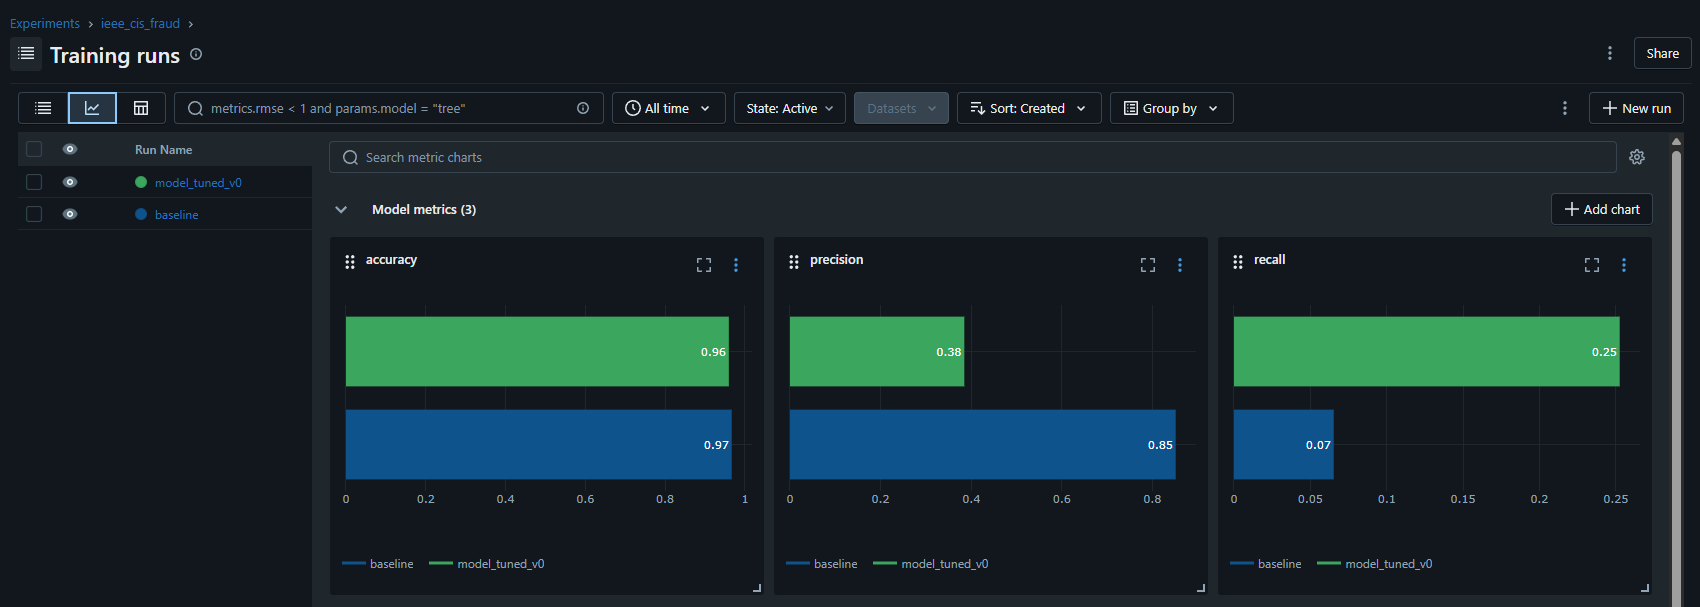